# PROJETO DE FINAL DE CURSO — Análise exploratória de dados com Python, NumPy, Pandas e Git
## Perfil dos Candidatos às Eleições Gerais 2026

CAIXA VERSO — Turma 1735 · Técnicas de Programação I (DS-PY-004)

**Integrantes:** Fabio de Paula Freitas · Flaviane Cristina Pereira Marra · Galvanir Machado Galvão

| Parte | Responsável |
|---|---|
| Itens 1 a 2.5 — Base, perguntas e diagnóstico de qualidade | Flaviane |
| Item 3 até a Hipótese 1 | Galvanir |
| Hipótese 2 até a Conclusão | Fabio |

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.width', 200)
pd.set_option('display.max_columns', 60)

## 1. Apresentação da base e perguntas

### 1.1 Origem dos dados
- **Fonte:** Tribunal Superior Eleitoral (TSE) — Portal de Dados Abertos, arquivo de candidatos.
- **Arquivo:** `dados/consulta_cand_2026_BRASIL.csv` (separador `;`, codificação `latin-1`).
- **Recorte:** Eleições Gerais 2026, 1º turno (04/10/2026), todo o Brasil. Cada linha é uma **candidatura**.
- **Por que essa base:** é pública, real e "suja" — tem códigos de valor ausente, colunas sem informação e números gravados em formato errado, o que permite mostrar o diagnóstico e a limpeza.

In [ ]:
df = pd.read_csv('../dados/consulta_cand_2026_BRASIL.csv', sep=';', encoding='latin-1', low_memory=False)
print(f'A base tem {df.shape[0]:,} linhas e {df.shape[1]} colunas.'.replace(',', '.'))
df.head()

A base tem 20.989 linhas e 50 colunas.


,DT_GERACAO,HH_GERACAO,ANO_ELEICAO,CD_TIPO_ELEICAO,NM_TIPO_ELEICAO,NR_TURNO,CD_ELEICAO,DS_ELEICAO,DT_ELEICAO,TP_ABRANGENCIA,...,CD_GRAU_INSTRUCAO,DS_GRAU_INSTRUCAO,CD_ESTADO_CIVIL,DS_ESTADO_CIVIL,CD_COR_RACA,DS_COR_RACA,CD_OCUPACAO,DS_OCUPACAO,CD_SIT_TOT_TURNO,DS_SIT_TOT_TURNO
0,05/10/2026,10:14:11,2026,2,ELEIÇÃO ORDINÁRIA,1,6259,Eleições Gerais Estaduais 2026,04/10/2026,ESTADUAL,...,-4,NÃO DIVULGÁVEL,-4,NÃO DIVULGÁVEL,-4,NÃO DIVULGÁVEL,-4,NÃO DIVULGÁVEL,-1,#NULO
1,05/10/2026,10:14:11,2026,2,ELEIÇÃO ORDINÁRIA,1,6259,Eleições Gerais Estaduais 2026,04/10/2026,ESTADUAL,...,8,SUPERIOR COMPLETO,1,SOLTEIRO(A),3,PARDA,257,EMPRESÁRIO,4,NÃO ELEITO
2,05/10/2026,10:14:11,2026,2,ELEIÇÃO ORDINÁRIA,1,6259,Eleições Gerais Estaduais 2026,04/10/2026,ESTADUAL,...,7,SUPERIOR INCOMPLETO,9,DIVORCIADO(A),1,BRANCA,591,ALFAIATE E COSTUREIRO,4,NÃO ELEITO
3,05/10/2026,10:14:11,2026,2,ELEIÇÃO ORDINÁRIA,1,6259,Eleições Gerais Estaduais 2026,04/10/2026,ESTADUAL,...,3,ENSINO FUNDAMENTAL INCOMPLETO,3,CASADO(A),1,BRANCA,169,COMERCIANTE,4,NÃO ELEITO
4,05/10/2026,10:14:11,2026,2,ELEIÇÃO ORDINÁRIA,1,6259,Eleições Gerais Estaduais 2026,04/10/2026,ESTADUAL,...,8,SUPERIOR COMPLETO,3,CASADO(A),3,PARDA,131,ADVOGADO,4,NÃO ELEITO


### 1.2 Dicionário das colunas principais
| Coluna | Significado | Tipo |
|---|---|---|
| `SG_UF` | Estado (sigla) da candidatura | categórica |
| `DS_CARGO` | Cargo disputado (deputado, senador, governador…) | categórica |
| `SG_PARTIDO` | Sigla do partido | categórica |
| `DS_GENERO` | Gênero declarado | categórica |
| `DS_COR_RACA` | Raça/cor declarada | categórica |
| `DS_GRAU_INSTRUCAO` | Grau de instrução declarado | categórica (ordinal) |
| `CD_GRAU_INSTRUCAO` | Código do grau de instrução | numérica |
| `DT_NASCIMENTO` | Data de nascimento (permite calcular a idade) | data |
| `NR_PARTIDO` | Número do partido | numérica |
| `DS_SIT_TOT_TURNO` | Resultado no 1º turno (eleito, suplente, não eleito…) | categórica |

### 1.3 Perguntas e hipóteses (definidas ANTES da análise)
1. **Qual é a distribuição de gênero entre os candidatos?**
   *Hipótese 1:* há maioria masculina, com mulheres pouco acima da cota mínima de 30%.
2. **Como está distribuída a raça/cor dos candidatos?**
   *Hipótese 2:* brancos e pardos concentram a grande maioria; indígenas e amarelos são minoria.
3. **Qual é o grau de instrução dos candidatos e ele muda conforme o cargo?**
   *Hipótese 3:* a maioria tem superior completo, e a proporção é maior nos cargos do Executivo.

## 2. Diagnóstico de qualidade
Objetivo: conhecer os problemas da base **antes** de mexer nela. Nesta etapa nada é alterado — tudo o que for encontrado aqui será tratado no item 3 (limpeza).

### 2.1 Tamanho, tipos e uso de memória

In [ ]:
print('Formato (linhas, colunas):', df.shape)
print(f"Memória usada: {df.memory_usage(deep=True).sum() / 1024**2:.1f} MB")
print('\nQuantidade de colunas por tipo:')
print(df.dtypes.value_counts())

Formato (linhas, colunas): (20989, 50)
Memória usada: 45.9 MB

Quantidade de colunas por tipo:
object    34
int64     16
Name: count, dtype: int64


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20989 entries, 0 to 20988
Data columns (total 50 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   DT_GERACAO                     20989 non-null  object
 1   HH_GERACAO                     20989 non-null  object
 2   ANO_ELEICAO                    20989 non-null  int64 
 3   CD_TIPO_ELEICAO                20989 non-null  int64 
 4   NM_TIPO_ELEICAO                20989 non-null  object
 5   NR_TURNO                       20989 non-null  int64 
 6   CD_ELEICAO                     20989 non-null  int64 
 7   DS_ELEICAO                     20989 non-null  object
 8   DT_ELEICAO                     20989 non-null  object
 9   TP_ABRANGENCIA                 20989 non-null  object
 10  SG_UF                          20989 non-null  object
 11  SG_UE                          20989 non-null  object
 12  NM_UE                          20989 non-null  object
 13  C

**Leitura:** a base tem 20.989 candidaturas e 50 colunas, atendendo ao mínimo de 1.000 linhas e 8 colunas. Há colunas numéricas e categóricas suficientes.
**Problema de tipo:** `DT_NASCIMENTO` está como texto (`object`) e precisará virar data. `SQ_CANDIDATO` e `SQ_COLIGACAO` estão como texto porque vieram em notação científica (próximo item).

### 2.2 Valores faltantes (quantidade e %)

In [ ]:
falt = pd.DataFrame({'faltantes': df.isna().sum(), 'faltantes_%': (df.isna().mean() * 100).round(2)})
print('Faltantes "visíveis" (NaN):')
print(falt[falt['faltantes'] > 0])

Faltantes "visíveis" (NaN):
               faltantes  faltantes_%
DT_NASCIMENTO          3         0.01


O `isna()` mostra quase nada, mas isso engana: o TSE **não deixa o campo vazio**, ele grava códigos no lugar do dado ausente — `NÃO DIVULGÁVEL`, `#NULO`, `#NE` e números negativos como `-1`, `-3` e `-4`. Por isso contei esses códigos como faltantes "escondidos".

In [ ]:
codigos = ['NÃO DIVULGÁVEL', 'Não divulgável', '#NULO', '#NE', -1, -3, -4, '-1', '-3', '-4']
ocultos = df.isin(codigos)
falt_ocultos = pd.DataFrame({
    'faltantes_ocultos': ocultos.sum(),
    'faltantes_%': (ocultos.mean() * 100).round(2)
}).query('faltantes_ocultos > 0').sort_values('faltantes_%', ascending=False)
print(falt_ocultos)

                               faltantes_ocultos  faltantes_%
DS_EMAIL                                   20989       100.00
DS_SITUACAO_CANDIDATURA                    20989       100.00
CD_SITUACAO_CANDIDATURA                    20989       100.00
NM_SOCIAL_CANDIDATO                        20934        99.74
NR_FEDERACAO                               14482        69.00
NM_FEDERACAO                               14482        69.00
SG_FEDERACAO                               14482        69.00
DS_COMPOSICAO_FEDERACAO                    14482        69.00
DS_SIT_TOT_TURNO                            1095         5.22
CD_SIT_TOT_TURNO                            1095         5.22
NR_CPF_CANDIDATO                               3         0.01
CD_GENERO                                      3         0.01
DS_GENERO                                      3         0.01
SG_UF_NASCIMENTO                               3         0.01
NR_TITULO_ELEITORAL_CANDIDATO                  3         0.01
DS_GRAU_

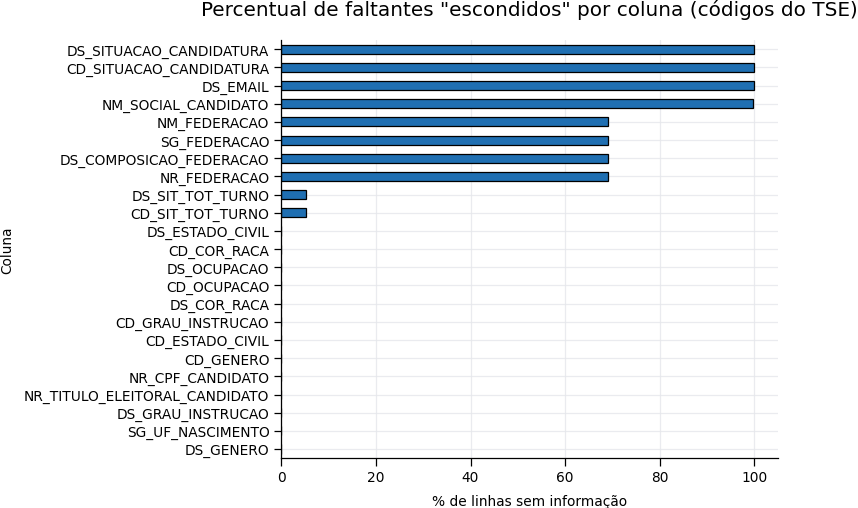

In [ ]:
fig, ax = plt.subplots(figsize=(9, 6))
falt_ocultos['faltantes_%'].sort_values().plot.barh(ax=ax, color='#1f6fb2')
ax.set_title('Percentual de faltantes "escondidos" por coluna (códigos do TSE)')
ax.set_xlabel('% de linhas sem informação'); ax.set_ylabel('Coluna')
plt.tight_layout(); plt.show()

**Leitura:**
- Algumas colunas estão **100% vazias** na prática (ex.: `DS_EMAIL`, `DS_SITUACAO_CANDIDATURA`) e não servem para a análise.
- Colunas como `NM_SOCIAL_CANDIDATO` e as de federação ficam "vazias" quando **não se aplicam** ao candidato (não tem nome social ou o partido não está em federação). Isso não é erro, é ausência esperada.
- As colunas das nossas perguntas (`DS_GENERO`, `DS_COR_RACA`, `DS_GRAU_INSTRUCAO`) têm só **3 linhas** sem informação (0,01%), e `DT_NASCIMENTO` tem 3 vazios.

In [ ]:
# As 3 linhas sem gênero/raça/instrução são as mesmas?
sem_info = df[df['DS_GENERO'].eq('NÃO DIVULGÁVEL')]
print('Linhas sem gênero:', len(sem_info))
print('Dessas, também sem raça e instrução:',
      (sem_info['DS_COR_RACA'].eq('NÃO DIVULGÁVEL') & sem_info['DS_GRAU_INSTRUCAO'].eq('NÃO DIVULGÁVEL')).sum())

Linhas sem gênero: 3
Dessas, também sem raça e instrução: 3


### 2.3 Duplicados

In [ ]:
print('Linhas 100% duplicadas:', df.duplicated().sum())
print('SQ_CANDIDATO repetido:', df['SQ_CANDIDATO'].duplicated().sum())
print('Exemplos de SQ_CANDIDATO:', df['SQ_CANDIDATO'].head(5).tolist())

cpf = pd.to_numeric(df['NR_CPF_CANDIDATO'], errors='coerce')
cpf_valido = cpf[cpf > 0]
print('\nCPFs válidos repetidos:', cpf_valido.duplicated().sum())

Linhas 100% duplicadas: 0
SQ_CANDIDATO repetido: 15383
Exemplos de SQ_CANDIDATO: ['1,30003E+11', '40002549901', '2,40003E+11', '2,10003E+11', '1,70003E+11']

CPFs válidos repetidos: 111


In [ ]:
# Quem tem o CPF repetido? (mesma pessoa em mais de uma candidatura?)
rep = df[cpf.isin(cpf_valido[cpf_valido.duplicated()])]
print(rep[['NR_CPF_CANDIDATO', 'NM_URNA_CANDIDATO', 'SG_UF', 'DS_CARGO']].sort_values('NR_CPF_CANDIDATO').head(10))

       NR_CPF_CANDIDATO  NM_URNA_CANDIDATO SG_UF           DS_CARGO
13385          24314161     LUCIENE KAYABI    MT   DEPUTADO FEDERAL
14258          24314161     LUCIENE KAYABI    MT  DEPUTADO ESTADUAL
3955          253242096  CATARINA PALADINI    RS  DEPUTADO ESTADUAL
15862         253242096  CATARINA PALADINI    RS   DEPUTADO FEDERAL
15630         643276980    MARCOS BAUMGART    PR        2º SUPLENTE
311           643276980    MARCOS BAUMGART    PR        1º SUPLENTE
10799         690013167      ALEX PUCINELI    MT    VICE-GOVERNADOR
10798         690013167      ALEX PUCINELI    MT    VICE-GOVERNADOR
5432          754446409   CORONEL DANIELLI    AL  DEPUTADO ESTADUAL
4719          754446409   CORONEL DANIELLI    AL   DEPUTADO FEDERAL


**Leitura:**
- Não há linhas 100% duplicadas.
- `SQ_CANDIDATO` (o identificador do TSE) aparece "repetido" milhares de vezes, mas **não é duplicidade real**: o número foi gravado em notação científica (ex.: `1,30003E+11`) e perdeu os últimos dígitos. A coluna está corrompida e **não pode ser usada como chave**.
- Para checar duplicidade de pessoa, o CPF é a chave confiável. Há **111 CPFs repetidos**: a mesma pessoa aparece em mais de uma candidatura (ex.: deputado federal e estadual ao mesmo tempo, ou 1º e 2º suplente). Há também casos no **mesmo cargo** (ex.: vice-governador registrado duas vezes), que parecem duplicidade de cadastro. Isso será tratado na limpeza.

### 2.4 Categorias inconsistentes e valores inválidos

In [ ]:
for col in ['DS_GENERO', 'DS_COR_RACA', 'DS_GRAU_INSTRUCAO', 'DS_CARGO']:
    print(f'--- {col} ---')
    print(df[col].value_counts(dropna=False), '\n')

--- DS_GENERO ---
DS_GENERO
MASCULINO         13619
FEMININO           7367
NÃO DIVULGÁVEL        3
Name: count, dtype: int64 

--- DS_COR_RACA ---
DS_COR_RACA
BRANCA            10533
PARDA              7309
PRETA              2842
INDÍGENA            195
AMARELA             107
NÃO DIVULGÁVEL        3
Name: count, dtype: int64 

--- DS_GRAU_INSTRUCAO ---
DS_GRAU_INSTRUCAO
SUPERIOR COMPLETO                12321
ENSINO MÉDIO COMPLETO             4508
SUPERIOR INCOMPLETO               2213
ENSINO MÉDIO INCOMPLETO            700
ENSINO FUNDAMENTAL INCOMPLETO      619
ENSINO FUNDAMENTAL COMPLETO        549
LÊ E ESCREVE                        76
NÃO DIVULGÁVEL                       3
Name: count, dtype: int64 

--- DS_CARGO ---
DS_CARGO
DEPUTADO ESTADUAL     11295
DEPUTADO FEDERAL       7803
DEPUTADO DISTRITAL      433
2º SUPLENTE             350
1º SUPLENTE             349
SENADOR                 319
VICE-GOVERNADOR         211
GOVERNADOR              201
PRESIDENTE               14
VICE-P

In [ ]:
# Espaços sobrando no início/fim dos textos
txt = df.select_dtypes('object')
espacos = txt.apply(lambda s: (s.str.len() != s.str.strip().str.len()).sum())
print('Colunas com espaços sobrando:')
print(espacos[espacos > 0])

# Colunas com um único valor (não ajudam a explicar nada)
print('\nColunas constantes:', [c for c in df.columns if df[c].nunique(dropna=False) == 1])

Colunas com espaços sobrando:
NM_CANDIDATO          1
NM_URNA_CANDIDATO     8
NM_COLIGACAO         25
DT_NASCIMENTO         3
dtype: int64

Colunas constantes: ['DT_GERACAO', 'HH_GERACAO', 'ANO_ELEICAO', 'CD_TIPO_ELEICAO', 'NM_TIPO_ELEICAO', 'NR_TURNO', 'DT_ELEICAO', 'DS_EMAIL', 'CD_SITUACAO_CANDIDATURA', 'DS_SITUACAO_CANDIDATURA']


In [ ]:
# Datas inválidas e idade na data da eleição
nasc = pd.to_datetime(df['DT_NASCIMENTO'], format='%d/%m/%Y', errors='coerce')
idade = (pd.Timestamp('2026-10-04') - nasc).dt.days // 365.25
print('Datas de nascimento que não viram data:', nasc.isna().sum())
print('Idades acima de 100 anos:', (idade > 100).sum())

# Idade mínima exigida pela Constituição para cada cargo (conferida na posse)
idade_min = {'DEPUTADO ESTADUAL': 21, 'DEPUTADO FEDERAL': 21, 'DEPUTADO DISTRITAL': 21,
             'GOVERNADOR': 30, 'VICE-GOVERNADOR': 30, 'SENADOR': 35, '1º SUPLENTE': 35,
             '2º SUPLENTE': 35, 'PRESIDENTE': 35, 'VICE-PRESIDENTE': 35}
# idade na posse (1º de janeiro de 2027 para todos os cargos, aproximação)
idade_posse = (pd.Timestamp('2027-01-01') - nasc).dt.days // 365.25
abaixo = idade_posse < df['DS_CARGO'].map(idade_min)
print('\nCandidaturas abaixo da idade mínima do cargo:', abaixo.sum())
print(df.loc[abaixo, 'DS_CARGO'].value_counts())
print('\nResumo da idade:')
print(idade.describe().round(1))

Datas de nascimento que não viram data: 3
Idades acima de 100 anos: 0

Candidaturas abaixo da idade mínima do cargo: 19
DS_CARGO
1º SUPLENTE          7
DEPUTADO ESTADUAL    5
DEPUTADO FEDERAL     4
2º SUPLENTE          3
Name: count, dtype: int64

Resumo da idade:
count    20986.0
mean        49.2
std         11.7
min         19.0
25%         41.0
50%         49.0
75%         57.0
max         92.0
Name: DT_NASCIMENTO, dtype: float64


**Leitura:**
- As categorias de gênero, raça/cor e instrução estão **padronizadas** (maiúsculas, sem variações de escrita). O único "intruso" é o código `NÃO DIVULGÁVEL`, que é dado ausente e não uma categoria.
- O `DS_CARGO` mistura "1º SUPLENTE" e "2º SUPLENTE" sem dizer que são suplentes **de senador** — será preciso agrupar os cargos na limpeza.
- Há colunas **constantes** (mesmo valor em todas as linhas), que não trazem informação e podem ser descartadas.
- Há **espaços sobrando** no início/fim de alguns textos (nomes e coligações), que precisam do `strip()`.
- As idades vão de 19 a 92 anos, sem valores absurdos; as datas que falharam são as 3 linhas vazias.
- **19 candidaturas** aparecem **abaixo da idade mínima exigida para o cargo** (suplentes de senador e deputados). Pode ser erro de cadastro ou candidatura que será barrada — vale sinalizar, mas o dado não permite afirmar qual.

### 2.5 Outliers (valores fora do padrão)
**Método escolhido: IQR (intervalo interquartil), aplicado dentro de cada cargo.**
- *Por que IQR e não z-score?* O z-score supõe distribuição simétrica (normal); a idade dos candidatos não é perfeitamente simétrica, e o IQR é menos influenciado pelos próprios extremos.
- *Por que por cargo?* A idade mínima e o perfil mudam conforme o cargo (ex.: 35 anos para presidente e senador, 21 para deputado). Comparar um candidato a presidente com deputados geraria falsos outliers. Por isso cada candidato é comparado só com quem disputa o mesmo cargo.

In [ ]:
tmp = pd.DataFrame({'DS_CARGO': df['DS_CARGO'], 'idade': idade})

def limites_iqr(s):
    q1, q3 = s.quantile([0.25, 0.75])
    iqr = q3 - q1
    return pd.Series({'Q1': q1, 'Q3': q3, 'lim_inf': q1 - 1.5 * iqr, 'lim_sup': q3 + 1.5 * iqr})

lim = tmp.groupby('DS_CARGO')['idade'].apply(limites_iqr).unstack()
tmp = tmp.join(lim[['lim_inf', 'lim_sup']], on='DS_CARGO')
tmp['outlier'] = np.where((tmp['idade'] < tmp['lim_inf']) | (tmp['idade'] > tmp['lim_sup']), 1, 0)

resumo_out = tmp.groupby('DS_CARGO').agg(candidatos=('idade', 'size'),
                                         outliers=('outlier', 'sum'),
                                         idade_min=('idade', 'min'),
                                         idade_max=('idade', 'max'))
print(lim.round(1).join(resumo_out))
print('\nTotal de outliers de idade:', tmp['outlier'].sum())

                      Q1    Q3  lim_inf  lim_sup  candidatos  outliers  idade_min  idade_max
DS_CARGO                                                                                    
1º SUPLENTE         43.8  62.0     16.4     89.4         349         0       31.0       89.0
2º SUPLENTE         43.0  64.0     11.5     95.5         350         0       31.0       85.0
DEPUTADO DISTRITAL  41.0  55.0     20.0     76.0         433         1       22.0       87.0
DEPUTADO ESTADUAL   41.0  57.0     17.0     81.0       11295        29       19.0       92.0
DEPUTADO FEDERAL    41.0  57.0     17.0     81.0        7803        20       19.0       89.0
GOVERNADOR          41.0  59.0     14.0     86.0         201         0       30.0       74.0
PRESIDENTE          42.8  68.8      3.8    107.8          14         0       39.0       80.0
SENADOR             46.0  64.0     19.0     91.0         319         1       35.0       92.0
VICE-GOVERNADOR     42.0  59.0     16.5     84.5         211         0

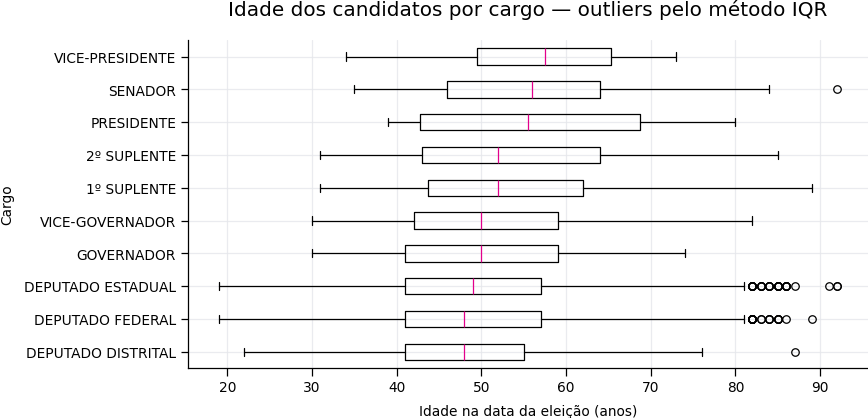

In [ ]:
ordem = tmp.groupby('DS_CARGO')['idade'].median().sort_values().index
fig, ax = plt.subplots(figsize=(10, 5))
ax.boxplot([tmp.loc[tmp['DS_CARGO'] == c, 'idade'].dropna() for c in ordem], vert=False)
ax.set_yticks(range(1, len(ordem) + 1)); ax.set_yticklabels(ordem)
ax.set_title('Idade dos candidatos por cargo — outliers pelo método IQR')
ax.set_xlabel('Idade na data da eleição (anos)'); ax.set_ylabel('Cargo')
plt.tight_layout(); plt.show()

**Leitura:** os pontos fora das "caixas" são os outliers de idade dentro de cada cargo. Eles são **valores possíveis** (candidatos muito jovens ou muito idosos para aquele cargo), e não erros de digitação. Por isso a recomendação é **manter** esses registros: removê-los apagaria candidatos reais.

# Etapa 3 – Limpeza e transformação
3.1 Colunas sem uso

**Decisão:**
remover colunas 100% sem informação (
DS_EMAIL
,
NM_SOCIAL_CANDIDATO
,
), a colunaestragada (
SQ_CANDIDATO
), dados pessoais sem uso (título eleitoral) e dados de geração do arquivo.

In [ ]:
df_limpo = df.drop(columns=['DT_GERACAO', 'HH_GERACAO', 'DS_EMAIL', 'NM_SOCIAL_CANDIDATO',
                            'CD_SITUACAO_CANDIDATURA', 'DS_SITUACAO_CANDIDATURA',
                            'SQ_CANDIDATO', 'NR_TITULO_ELEITORAL_CANDIDATO']).copy()
print('Colunas antes:', df.shape[1], '| depois:', df_limpo.shape[1])

# 3.2 Padronização de categorias

**Decisão:** tirar espaços sobrando de todos os textos (apply com str.strip) e trocar todos os códigos de faltante por vazio (NaN). Assim "NÃO DIVULGÁVEL" não aparece como se fosse uma categoria nos gráficos.

In [ ]:
colunas_texto = df_limpo.select_dtypes('object').columns
df_limpo[colunas_texto] = df_limpo[colunas_texto].apply(lambda coluna: coluna.str.strip())
df_limpo = df_limpo.replace(codigos_faltante, np.nan).infer_objects()

texto = df_limpo['NM_COLIGACAO'].fillna('')
print('Espaços sobrando depois da limpeza:', (texto != texto.str.strip()).sum())
print(df_limpo[['DS_GENERO', 'DS_COR_RACA', 'DS_GRAU_INSTRUCAO']].isna().sum())

# 3.3 Duplicados

**Decisão:** a mesma pessoa no mesmo cargo é uma única candidatura. Entre as duas linhas, mantemos a que tem resultado, porque a linha "#NULO" é o registro substituído. Quem aparece em cargos diferentes (ex.: senador e suplente) foi mantido, porque são candidaturas diferentes.

In [ ]:
linhas_antes = len(df_limpo)
df_limpo['_tem_resultado'] = df_limpo['DS_SIT_TOT_TURNO'].notna()
df_limpo = (df_limpo.sort_values('_tem_resultado', ascending=False)
                    .drop_duplicates(['NR_CPF_CANDIDATO', 'DS_CARGO'], keep='first')
                    .drop(columns='_tem_resultado'))
print('Linhas antes:', linhas_antes, '| depois:', len(df_limpo), '| removidas:', linhas_antes - len(df_limpo))

# 3.4 Faltantes
**Comparação de estratégias:**

**Imputar** (preencher com a categoria mais comum): inventaria gênero e raça de uma pessoa real — não faz sentido para dado pessoal.

**Remover:** são só 3 linhas. Medimos o impacto abaixo antes de decidir.

In [ ]:
sem_perfil = df_limpo['DS_GENERO'].isna()
print('Linhas sem gênero/raça/instrução:', sem_perfil.sum())
print(df_limpo.loc[sem_perfil, ['NM_CANDIDATO', 'DS_CARGO', 'SG_UF']])

antes = df_limpo['DS_GENERO'].value_counts(normalize=True).mul(100).round(2)
depois = df_limpo.loc[~sem_perfil, 'DS_GENERO'].value_counts(normalize=True).mul(100).round(2)
print('\nImpacto da remoção no % de gênero:')
print(pd.DataFrame({'antes': antes, 'depois': depois}))

df_limpo = df_limpo[~sem_perfil]
print('\nLinhas finais:', len(df_limpo))

**Decisão:** remover as 3 linhas. O impacto nas proporções é praticamente zero (menos de 0,02% da base).

# 3.5 Outliers

**Decisão:** não remover. As idades extremas são reais e permitidas por lei (candidatos com mais de 80 anos), não erros de digitação. Apenas marcamos os outliers numa coluna nova, para quem quiser filtrar.

## 3.6 Colunas derivadas

| Coluna nova | Como foi feita |
|---|---|
| `IDADE` | Data da eleição menos data de nascimento |
| `FAIXA_ETARIA` | `pd.cut` em faixas de idade |
| `NIVEL_INSTRUCAO` | `map` agrupando 7 níveis em 3 |
| `TIPO_CARGO` | `np.select` agrupando os cargos |
| `SUPERIOR_COMPLETO` | `np.where` (1 = sim, 0 = não) |
| `OUTLIER_IDADE` | IQR por cargo |
| `Z_IDADE` | z-score da idade por cargo, calculado com NumPy |

In [ ]:
df_limpo['DT_NASCIMENTO'] = pd.to_datetime(df_limpo['DT_NASCIMENTO'], format='%d/%m/%Y', errors='coerce')
df_limpo['IDADE'] = (pd.Timestamp('2026-10-04') - df_limpo['DT_NASCIMENTO']).dt.days // 365

df_limpo['FAIXA_ETARIA'] = pd.cut(df_limpo['IDADE'], bins=[17, 29, 39, 49, 59, 69, 120],
                                  labels=['18-29', '30-39', '40-49', '50-59', '60-69', '70+'])

mapa_instrucao = {
    'LÊ E ESCREVE': 'Fundamental ou menos',
    'ENSINO FUNDAMENTAL INCOMPLETO': 'Fundamental ou menos',
    'ENSINO FUNDAMENTAL COMPLETO': 'Fundamental ou menos',
    'ENSINO MÉDIO INCOMPLETO': 'Médio',
    'ENSINO MÉDIO COMPLETO': 'Médio',
    'SUPERIOR INCOMPLETO': 'Médio',
    'SUPERIOR COMPLETO': 'Superior completo',
}
df_limpo['NIVEL_INSTRUCAO'] = df_limpo['DS_GRAU_INSTRUCAO'].map(mapa_instrucao)

condicoes = [
    df_limpo['DS_CARGO'].isin(['PRESIDENTE', 'VICE-PRESIDENTE', 'GOVERNADOR', 'VICE-GOVERNADOR']),
    df_limpo['DS_CARGO'].isin(['SENADOR', '1º SUPLENTE', '2º SUPLENTE']),
]
df_limpo['TIPO_CARGO'] = np.select(condicoes, ['Executivo', 'Senado'], default='Deputados')

df_limpo['SUPERIOR_COMPLETO'] = np.where(df_limpo['DS_GRAU_INSTRUCAO'] == 'SUPERIOR COMPLETO', 1, 0)

df_limpo['OUTLIER_IDADE'] = df_limpo.groupby('DS_CARGO')['IDADE'].transform(outlier_iqr)

# z-score vetorizado com NumPy: calcula todas as linhas de uma vez, sem laço for
media = df_limpo.groupby('DS_CARGO')['IDADE'].transform('mean').to_numpy()
desvio = df_limpo.groupby('DS_CARGO')['IDADE'].transform('std').to_numpy()
df_limpo['Z_IDADE'] = np.round((df_limpo['IDADE'].to_numpy() - media) / desvio, 2)

df_limpo[['IDADE', 'FAIXA_ETARIA', 'NIVEL_INSTRUCAO', 'TIPO_CARGO', 'SUPERIOR_COMPLETO', 'OUTLIER_IDADE', 'Z_IDADE']].head()